**Group information**

| Family name | First name | Email address |
| ----------- | ---------- | ------------- |
|             |            |               |
|             |            |               |
|             |            |               |

# Convolutional networks - Solutions

In this tutorial we explore how computer vision models can be used to predict emotions from facial images. The labelled dataset available on [Kaggle](https://www.kaggle.com/datasets/jonathanoheix/face-expression-recognition-dataset) contains 35,887 images of dimensions $48 \times 48 \times 3$, representing faces expressing 7 fundamental emotions including anger, disgust, fear, happiness, neutral, sadness, and surprise. We aim to approximate the function mapping each image to a set of conditional probabilities corresponding to each emotion using a simple convolutional neural network.

In [1]:
# Packages
import numpy as np
import pandas as pd
import os
import shutil
import torch
import torchinfo

from matplotlib import pyplot as plt
from sklearn import metrics
from torch import nn, optim, utils
from torchvision import io, transforms
from tqdm import tqdm
from urllib import request

# Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
device = torch.device(device)

# Utilities
emotions = {0:'Anger', 1:'Disgust', 2:'Fear', 3:'Happiness', 4:'Neutral', 5:'Sadness', 6:'Surprise'}

In [ ]:
# Utilities
def plot_image(image:torch.Tensor, title:str='', cmap:str='gray', figsize=(5, 5)) -> None:
    image   = torch.einsum('dhw -> hwd', image)
    fig, ax = plt.subplots(1, figsize=figsize)
    ax.imshow(image, cmap='gray')
    ax.set_title(title, fontsize=15)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
    plt.close()

def download_data():
    if os.getcwd().endswith('/data'):
        print('Data folder already exists')
    else:
        request.urlretrieve('https://www.dropbox.com/scl/fo/tx9jd90dcikchryb2ljul/ACOnY-43BZ9L3eY2WwuMLTY?rlkey=7lv28by0zfm4p8wlj1fpmca3a&dl=1', 'data.zip')
        shutil.unpack_archive('data.zip', 'data')
        os.remove('data.zip')
        os.chdir('data')

In [3]:
# Downloads dataset
os.chdir(os.path.expanduser('~/Dropbox/teaching/image_analysis/4_convnet/convnet_practice/convnet_data'))
# download_data()

**1. Load data:** Use `torch.load` to load the images and labels tensors.

In [4]:
# Loads dataset
images = torch.load('emotion_images.pt')
labels = torch.load('emotion_labels.pt')

**2. Descriptive statistics:** Check the dimensions of images and labels tensors using the `size` methods, calculate label frequencies, and display a few image-label examples using the provided `plot_image` function.

Images shape: torch.Size([35887, 1, 48, 48])
Labels shape: torch.Size([35887])
Labels frequencies:
3    8989
4    6198
5    6077
2    5121
0    4953
6    4002
1     547
Name: count, dtype: int64


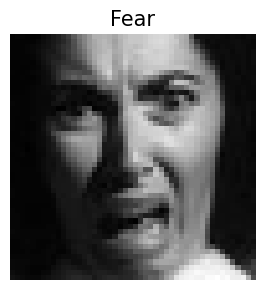

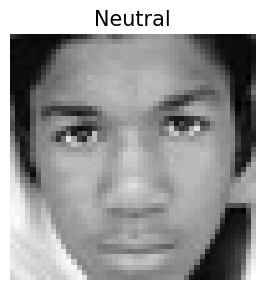

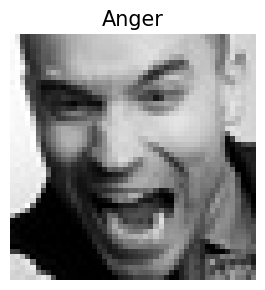

In [5]:
# Displays descriptive statistics
print('Images shape:', images.size())
print('Labels shape:', labels.size())
print('Labels frequencies:', pd.Series(labels).value_counts(), sep='\n')

# Displays random images and labels
for i in torch.randint(0, len(images), (3,)):
    plot_image(image=images[i], title=emotions.get(labels[i].item()), figsize=(3, 3))
del i

**3. Data formatting:** Convert the images tensor to `torch.float32` and normalise them to the `[0, 1]` range. Convert the labels tensor to `torch.int64` (or `torch.long`) as required by the cross-entropy loss function.

In [6]:
# Formats images and labels
images  = images.float() / 255.0
labels  = labels.long()
weights = torch.unique(labels, return_counts=True)[1]
weights = weights.max() / weights

**4. Train-test split:** Randomly partition images and labels into a training sample (75%) and a test sample (25%). Create PyTorch datasets (`utils.data.TensorDataset`) and data loaders (`utils.data.DataLoader`).

In [7]:
# Draw training and test indices
np.random.seed(0)
samples = np.random.choice(['train', 'test'], len(images), p=[0.75, 0.25])

# Initialises datasets
train_dataset = utils.data.TensorDataset(images[samples=='train'], labels[samples=='train'])
test_dataset  = utils.data.TensorDataset(images[samples=='test'],  labels[samples=='test'])

# Initialises data loader
train_loader  = utils.data.DataLoader(dataset=train_dataset, batch_size=256, shuffle=True)
test_loader   = utils.data.DataLoader(dataset=test_dataset,  batch_size=256, shuffle=False)

''' Checks datasets
x, y = train_dataset[:32] # First 32 observations
x, y = next(iter(train_loader)) # Next batch
print(f'Images shape: {x.size()}\nLabels shape: {y.size()}')
del x, y
'''

" Checks datasets\nx, y = train_dataset[:32] # First 32 observations\nx, y = next(iter(train_loader)) # Next batch\nprint(f'Images shape: {x.size()}\nLabels shape: {y.size()}')\ndel x, y\n"

**5. Model structure:** Define a PyTorch model class for a simple convolutional network with the following structure:

- Three blocks of layers with $d = 8, 16, 32$ convolutional filters, respectively:
    - Convolution (`nn.Conv2d`) with $d$ filters of size $3 \times 3$
    - ReLU activation (`nn.ReLU`)
    - $2 \times 2$ max pooling (`nn.MaxPool2d`)
- A global average pooling layer (`nn.AdaptiveAvgPool2d`)
- A linear output layer (`nn.Linear`)

Instantiate the model and print the model structure.

Note: For numerical stability, PyTorch loss functions expect raw logit scores rather than probability distributions. The softmax transformation is applied internally within the loss function.

In [8]:
# Defines model structure

def conv_block(in_channels:int, out_channels:int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, padding=0),
        nn.Dropout2d(p=0.1)
    )

class SimpleConvNet(nn.Module):
    
    def __init__(self, input_channels:int, num_outputs:int) -> None:
        super().__init__()
        self.conv_block1  = conv_block(input_channels, 8)
        self.conv_block2  = conv_block(8, 16)
        self.conv_block3  = conv_block(16, 32)
        self.conv_block4  = conv_block(32, 64)
        self.global_pool  = nn.AdaptiveAvgPool2d(1)
        self.output_layer = nn.Linear(64, num_outputs)

    def forward(self, x:torch.Tensor) -> torch.Tensor:
        h = self.conv_block1(x)   # [n,  1, 48, 48] -> [n,  8, 24, 24]
        h = self.conv_block2(h)   # [n,  8, 24, 24] -> [n, 16, 12, 12]
        h = self.conv_block3(h)   # [n, 16, 12, 12] -> [n, 32,  6,  6]
        h = self.conv_block4(h)   # [n, 32,  6,  6] -> [n, 64,  3,  3]
        h = self.global_pool(h)   # [n, 64,  3,  3] -> [n, 64,  1,  1]
        h = h.view(h.size(0), -1) # [n, 64,  1,  1] -> [n, 64]
        y = self.output_layer(h)  # [n, 64]         -> [n, 7]
        return y

# Instantiates model
model = SimpleConvNet(input_channels=1, num_outputs=len(emotions))
model = model.to(device)

# Prints model summary
torchinfo.summary(model, input_size=(1, *images.shape[1:]), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
SimpleConvNet                            [1, 7]                    --
├─Sequential: 1-1                        [1, 8, 24, 24]            --
│    └─Conv2d: 2-1                       [1, 8, 48, 48]            80
│    └─ReLU: 2-2                         [1, 8, 48, 48]            --
│    └─MaxPool2d: 2-3                    [1, 8, 24, 24]            --
│    └─Dropout2d: 2-4                    [1, 8, 24, 24]            --
├─Sequential: 1-2                        [1, 16, 12, 12]           --
│    └─Conv2d: 2-5                       [1, 16, 24, 24]           1,168
│    └─ReLU: 2-6                         [1, 16, 24, 24]           --
│    └─MaxPool2d: 2-7                    [1, 16, 12, 12]           --
│    └─Dropout2d: 2-8                    [1, 16, 12, 12]           --
├─Sequential: 1-3                        [1, 32, 6, 6]             --
│    └─Conv2d: 2-9                       [1, 32, 12, 12]           4,640
│    └─Re

**6. Loss function and optimiser:** Define the appropriate loss function (`nn.CrossEntropyLoss`) and an optimisation algorithm (e.g. `optim.AdamW`).

In [9]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss(reduction='mean', weight=weights.to(device))
optimiser = optim.AdamW(model.parameters(), lr=1e-3)

**7. Model training:** Write a PyTorch training loop to estimate the model parameters using the training sample, with a maximum of 100 epochs. 

Note: When using `cuda` or `mps` devices, make sure to move both the model and the input tensors to the appropriate device, and to move back the output tensor to `cpu`.

**8. Model evaluation:** Write a PyTorch evaluation loop to assess the model's generalisation performance on the test sample.

In [10]:
# Loads pre-trained model
state_dict = torch.load('emotion_model.pth', map_location=device)
model.load_state_dict(state_dict)

# Evaluation loop
model.eval()
P_test = []
tot_loss, num_obs = 0, 0
progress_bar = tqdm(test_loader, desc='Test', unit='batch')
# Iterate through batches
with torch.no_grad():
    for x, y in progress_bar:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss   = criterion(logits, y)
        probs  = torch.softmax(logits, dim=1)
        P_test.append(probs)
        # Statistics
        tot_loss += loss.item() * x.size(0)
        num_obs  += x.size(0)
        progress_bar.set_postfix(loss=f'{tot_loss / num_obs:.4f}')

# Formats predictions
Y_test  = test_dataset[:][1]
P_test  = torch.cat(P_test).detach().cpu()
Yh_test = torch.argmax(P_test, dim=1).detach().cpu()

Test: 100%|██████████| 35/35 [00:00<00:00, 35.15batch/s, loss=1.2760]


**9. Confusion matrix:** Display a sample of test images alongside their predicted labels. Compute the confusion matrix and interpret the results.

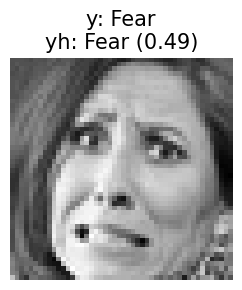

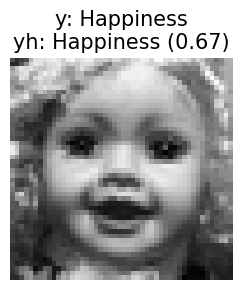

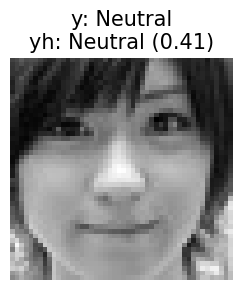

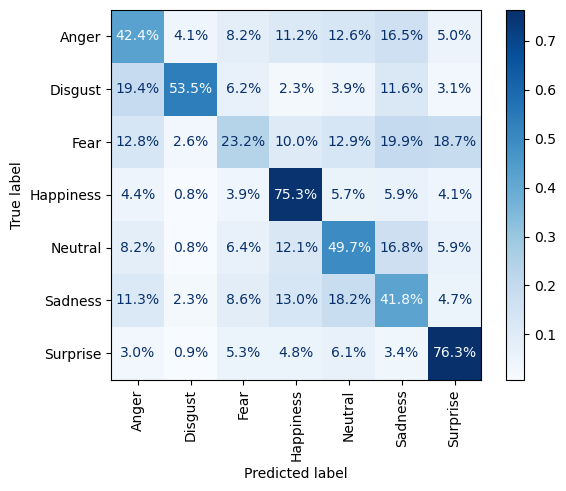

In [11]:
# Displays random predictions
for i in torch.randint(0, len(Yh_test), (3,)):
  y  = emotions.get(Y_test[i].item())
  yh = emotions.get(Yh_test[i].item())
  p  = P_test[i].max().item()
  plot_image(image=test_dataset[i][0], title=f'y: {y}\nyh: {yh} ({p:.2f})', figsize=(3, 3))
del i, y, yh, p

# Displays confusion matrix
metrics.ConfusionMatrixDisplay.from_predictions(Y_test, Yh_test, display_labels=emotions.values(), normalize='true', values_format='.1%', cmap='Blues', xticks_rotation='vertical')

**Bonus (intermediate)**: Predict the emotion of a custom image.

/var/folders/1n/bdzxxfgd22jcp5d0bkj39dn00000gs/T/ipykernel_8309/1234097054.py:8: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1742908989713/work/torch/csrc/utils/tensor_new.cpp:1567.)
  image = io.decode_image(torch.frombuffer(image, dtype=torch.uint8))


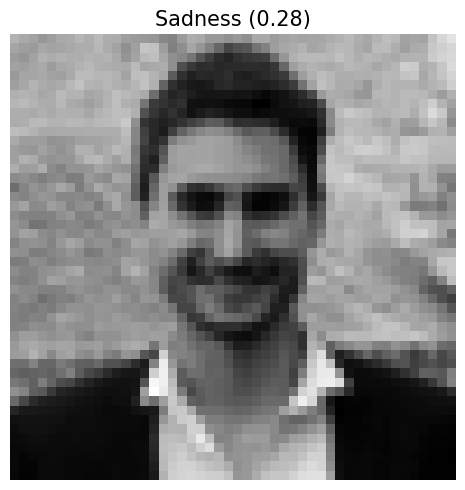

In [12]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48))
])

with request.urlopen('https://s7d1.scene7.com/is/image/wbcollab/Clement_Gorin_0?qlt=90&fmt=webp&resMode=sharp2') as response:
    image = response.read()
    image = io.decode_image(torch.frombuffer(image, dtype=torch.uint8))
    image = transform(image) / 255.0
del response

# Predicts image
yh = model(image.unsqueeze(0).to(device))
yh = torch.softmax(yh, dim=1)

plot_image(image=image, title=f'{emotions.get(torch.argmax(yh, dim=1).item())} ({yh.max().item():.2f})')
del image, yh

**Bonus (advanced)**:  Use a PyTorch hook to extract the output of the last hidden layer. Apply a distance-preserving dimensionality reduction technique (e.g. UMAP or t-SNE) to visualise the resulting embedding space.

In [13]:
# Packages
import plotly.graph_objects as go
import umap

# Register hook
def hook_fn(module:nn.Module, input:torch.Tensor) -> None:
    features.append(input[0].detach().cpu())
hook = model.output_layer.register_forward_pre_hook(hook_fn)

# Extracts features
features = []
with torch.no_grad():
    for x, y in tqdm(test_loader, desc='Prediction'):
        model(x.to(device))
features = torch.cat(features)
hook.remove()

# Displays features
projector = umap.UMAP(n_neighbors=50, n_components=3, metric='cosine')
figdata = projector.fit_transform(features)
figdata = pd.DataFrame({
    'umap1': figdata[:, 0],
    'umap2': figdata[:, 1],
    'umap3': figdata[:, 2],
    'label': Y_test
})

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=figdata.umap1,
    y=figdata.umap2,
    z=figdata.umap3,
    mode='markers',
    text=figdata.label.map(emotions),
    hoverinfo='text',
    marker=dict(
        color=figdata.label,
        size=2, 
        opacity=0.75,
        colorbar=dict(
            title='Emotion',
            tickvals=list(emotions.keys()),
            ticktext=list(emotions.values())
        )
    )
))
fig.update_layout(
    title='UMAP visualisation of the embedding space',
    scene=dict(
        xaxis=dict(title='UMAP1', showticklabels=False),
        yaxis=dict(title='UMAP2', showticklabels=False),
        zaxis=dict(title='UMAP3', showticklabels=False)
    ),
    template='plotly_dark',
    autosize=True
)
fig.show()
fig.write_html('emotion_umap.html')


Prediction: 100%|██████████| 35/35 [00:00<00:00, 277.51it/s]
/Users/goclem/Software/miniconda3/envs/deeplearning/lib/python3.12/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
